Creating decision variables...
Created 4000 production variables
Created 4000 processing variables
Created 2000 setup variables
Created 5000 inventory variables
Creating objective function...
Objective function created.
Creating constraints...
Created 61364 constraints
Solving MILP model...
Problem size: 17000 variables, 61364 constraints
Solution Status: Optimal
Optimal Objective Value: $-1090810.40

OPTIMIZATION RESULTS SUMMARY
Total Profit: $-1090810.40
Total Production: {0: 0, 1: 0}
Total Sales: {0: 0, 1: 0}
Demand Fulfillment: {0: 0.0, 1: 0.0}

Production Schedule by Machine:

Machine 0:
  Product 1: 16.0 batches = 64.0 units

Machine 1:

Machine 2:

Machine 3:


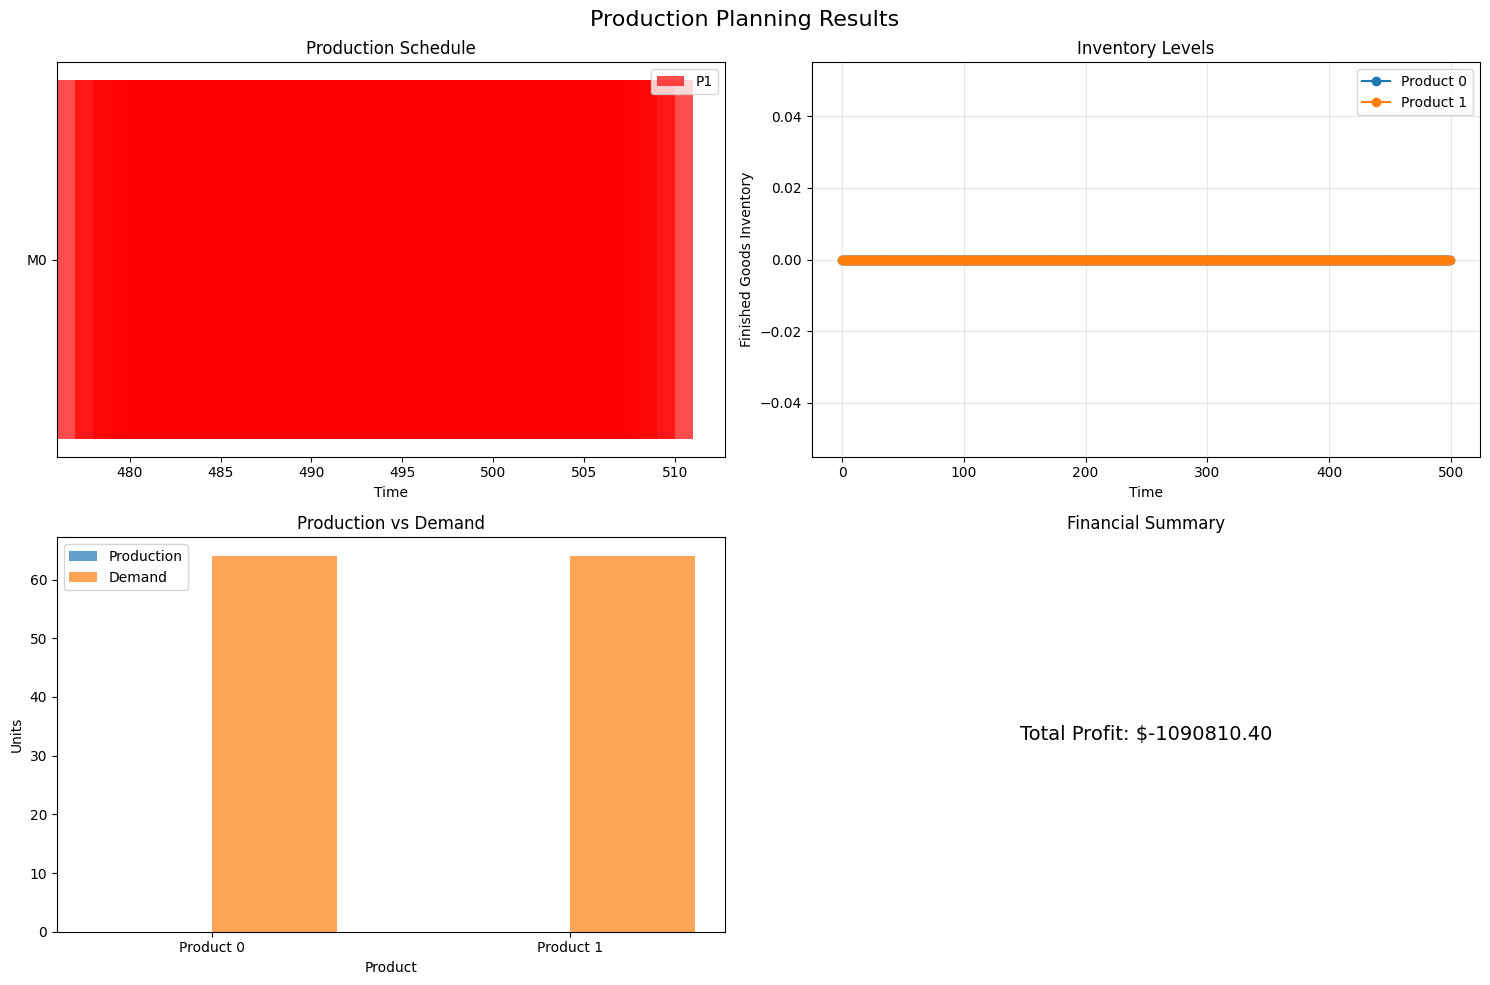

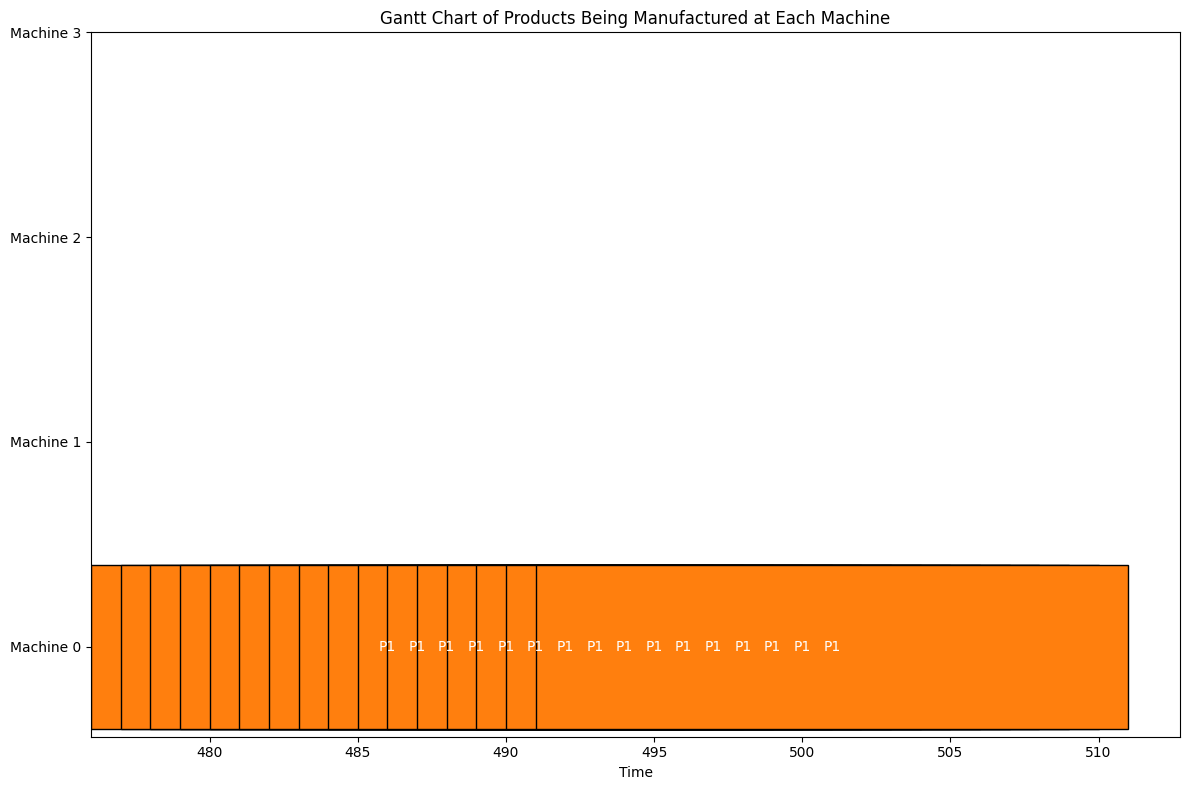

In [ ]:
import pulp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional, Any

# <<< NEW: bring in the same config factory used by the simulation
def make_common_config(mode: str = "ALL_AT_T0", H: int = 100) -> Dict[str, Any]:
    common = {
        'time_horizon': H,
        'machines': [0, 1, 2, 3],
        'products': [0, 1],
        'processing_times': {
            0: {0: 16, 1: 20},
            1: {0: 2,  1: 2},
            2: {0: 16, 1: 20},
            3: {0: 2,  1: 2},
        },
        'batch_sizes': {0: 4, 1: 1, 2: 4, 3: 1},
        'setup_times': {
            0: {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}},
            1: {0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}},
            2: {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}},
            3: {0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}},
        },
        'revenue_per_unit': {0: 50, 1: 60},
        'production_cost': {
            0: {0: 8,  1: 10},
            1: {0: 4,  1: 4},
            2: {0: 8,  1: 10},
            3: {0: 4,  1: 4},
        },
        'setup_cost': {0: 0, 1: 20, 2: 0, 3: 20},
        'inventory_cost_per_unit': {0: 0.5, 1: 0.6},
        'backorder_cost_per_unit': {0: 15, 1: 18},
        'initial_inventory': {
            0: {0: 0, 1: 0},
            1: {0: 0, 1: 0},
            2: {0: 0, 1: 0},
            3: {0: 0, 1: 0},
            'finished': {0: 0, 1: 0},
        },
        'arrivals_schedule': {},
        'demand_schedule': {},
    }

    TOTAL_0, TOTAL_1 = 64, 64
    def zero(n: int): return [0]*n

    if mode.upper() == "ALL_AT_T0":
        arr0 = zero(H); arr1 = zero(H); dem0 = zero(H); dem1 = zero(H)
        arr0[0] = TOTAL_0; arr1[0] = TOTAL_1
        dem0[0] = TOTAL_0; dem1[0] = TOTAL_1
    elif mode.upper() == "UNIFORM":
        base0, r0 = divmod(TOTAL_0, H)
        base1, r1 = divmod(TOTAL_1, H)
        arr0 = [base0 + (1 if t < r0 else 0) for t in range(H)]
        arr1 = [base1 + (1 if t < r1 else 0) for t in range(H)]
        dem0 = arr0[:]; dem1 = arr1[:]
    else:
        raise ValueError("mode must be ALL_AT_T0 or UNIFORM")

    common['arrivals_schedule'] = {0: arr0, 1: arr1}
    common['demand_schedule']   = {0: dem0, 1: dem1}
    # keep totals for reporting (optional)
    common['demand'] = {0: TOTAL_0, 1: TOTAL_1}
    return common
# <<< END NEW


# ---------- MILP CLASS ----------
class ProductionPlanningMILP:
    """
    Mixed Integer Linear Programming model for 4-machine production line
    with revenue maximization objective
    """
    def __init__(self, config: Optional[Dict[str, Any]] = None):
        # Default configuration (will be overridden by common config we pass in)
        self.default_config = {
            'time_horizon': 50,
            'machines': [0, 1, 2, 3],
            'products': [0, 1],
            'processing_times': {
                0: {0: 16, 1: 20},
                1: {0: 2, 1: 2},
                2: {0: 16, 1: 20},
                3: {0: 2, 1: 2}
            },
            'batch_sizes': {0: 4, 1: 1, 2: 4, 3: 1},
            'setup_times': {
                0: {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}},
                1: {0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}},
                2: {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}},
                3: {0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}}
            },
            'demand': {0: 64, 1: 64},
            'revenue_per_unit': {0: 50, 1: 60},
            'production_cost': {
                0: {0: 8, 1: 10},
                1: {0: 4, 1: 4},
                2: {0: 8, 1: 10},
                3: {0: 4, 1: 4}
            },
            'setup_cost': {0: 0, 1: 20, 2: 0, 3: 20},
            'inventory_cost_per_unit': {0: 0.5, 1: 0.6},
            'backorder_cost_per_unit': {0: 15, 1: 18},
            'initial_inventory': {
                0: {0: 0, 1: 0},   # zero by default so it's consistent if common isn't passed
                1: {0: 0, 1: 0},
                2: {0: 0, 1: 0},
                3: {0: 0, 1: 0},
                'finished': {0: 0, 1: 0}
            },
            # keys expected by our constraints when we pass common
            'arrivals_schedule': {0: [], 1: []},
            'demand_schedule': {0: [], 1: []},
        }

        self.config = self.default_config.copy()
        if config:
            self.config.update(config)

        self.T = range(self.config['time_horizon'])
        self.M = self.config['machines']
        self.P = self.config['products']

        self.prob = pulp.LpProblem("Production_Revenue_Maximization", pulp.LpMaximize)

        self.x = {}
        self.y = {}
        self.z = {}
        self.I = {}
        self.S = {}
        self.B = {}

    def create_variables(self):
        print("Creating decision variables...")

        # Start at most one batch at time t
        self.x = pulp.LpVariable.dicts(
            "production",
            [(m, j, t) for m in self.M for j in self.P for t in self.T],
            lowBound=0, upBound=1, cat='Binary'
        )

        self.y = pulp.LpVariable.dicts(
            "processing",
            [(m, j, t) for m in self.M for j in self.P for t in self.T],
            cat='Binary'
        )

        self.z = pulp.LpVariable.dicts(
            "setup",
            [(m, i, j, t) for m in [1, 3] for i in self.P for j in self.P for t in self.T if i != j],
            cat='Binary'
        )

        self.I = pulp.LpVariable.dicts(
            "inventory",
            [(m, j, t) for m in self.M + ['finished'] for j in self.P for t in self.T],
            lowBound=0, cat='Continuous'
        )

        self.S = pulp.LpVariable.dicts(
            "sales",
            [(j, t) for j in self.P for t in self.T],
            lowBound=0, cat='Continuous'
        )

        self.B = pulp.LpVariable.dicts(
            "backorder",
            [(j, t) for j in self.P for t in self.T],
            lowBound=0, cat='Continuous'
        )

        print(f"Created {len(self.x)} production variables")
        print(f"Created {len(self.y)} processing variables")
        print(f"Created {len(self.z)} setup variables")
        print(f"Created {len(self.I)} inventory variables")

    def create_objective_function(self):
        print("Creating objective function...")

        revenue = pulp.lpSum([
            self.config['revenue_per_unit'][j] * self.S[(j, t)]
            for j in self.P for t in self.T
        ])

        production_costs = pulp.lpSum([
            self.config['production_cost'][m][j] * self.x[(m, j, t)]
            for m in self.M for j in self.P for t in self.T
        ])

        setup_costs = pulp.lpSum([
            self.config['setup_cost'][m] * self.z[(m, i, j, t)]
            for m in [1, 3] for i in self.P for j in self.P for t in self.T if i != j
        ])

        inventory_costs = pulp.lpSum([
            self.config['inventory_cost_per_unit'][j] * self.I[(m, j, t)]
            for m in self.M + ['finished'] for j in self.P for t in self.T
        ])

        backorder_costs = pulp.lpSum([
            self.config['backorder_cost_per_unit'][j] * self.B[(j, t)]
            for j in self.P for t in self.T
        ])

        self.prob += (revenue - production_costs - setup_costs - inventory_costs - backorder_costs,
                      "Total_Profit")

        print("Objective function created.")

    def create_constraints(self):
        print("Creating constraints...")

        # 1) Machine capacity
        for m in self.M:
            for t in self.T:
                self.prob += (
                    pulp.lpSum([self.y[(m, j, t)] for j in self.P]) <= 1,
                    f"Machine_Capacity_M{m}_T{t}"
                )

        # 2) Production-processing linkage
        for m in self.M:
            for j in self.P:
                for t in self.T:
                    pt = self.config['processing_times'][m][j]
                    self.prob += (self.y[(m, j, t)] >= self.x[(m, j, t)],
                                  f"StartImpliesBusyAtStart_M{m}_P{j}_T{t}")
                    for tau in range(t, min(t + pt, len(self.T))):
                        self.prob += (self.y[(m, j, tau)] >= self.x[(m, j, t)],
                                      f"ProcessingWindow_M{m}_P{j}_T{t}_Tau{tau}")

        # 3) Setup constraints (machines 1 and 3)
        for m in [1, 3]:
            for t in range(1, len(self.T)):
                for i in self.P:
                    for j in self.P:
                        if i != j:
                            self.prob += (
                                self.z[(m, i, j, t)] >= self.y[(m, j, t)] - self.y[(m, i, t-1)],
                                f"Setup_Trigger_M{m}_P{i}_to_P{j}_T{t}"
                            )
                            self.prob += (self.z[(m, i, j, t)] <= self.y[(m, j, t)],
                                          f"SetupUB_now_M{m}_i{i}_j{j}_T{t}")
                            self.prob += (self.z[(m, i, j, t)] <= self.y[(m, i, t-1)],
                                          f"SetupUB_prev_M{m}_i{i}_j{j}_T{t}")

        # 4) Inventory flow
        for j in self.P:
            for t in self.T:
                arrivals0_t = self.config['arrivals_schedule'][j][t] if self.config['arrivals_schedule'][j] else 0
                if t == 0:
                    self.prob += (
                        self.I[(0, j, t)] ==
                        self.config['initial_inventory'][0][j] + arrivals0_t
                        - self.x[(0, j, t)] * self.config['batch_sizes'][0],
                        f"Inventory_Queue0_P{j}_T{t}"
                    )
                else:
                    self.prob += (
                        self.I[(0, j, t)] ==
                        self.I[(0, j, t-1)] + arrivals0_t
                        - self.x[(0, j, t)] * self.config['batch_sizes'][0],
                        f"Inventory_Queue0_P{j}_T{t}"
                    )

                # Intermediate queues
                for m in [1, 2, 3]:
                    p_prev = self.config['processing_times'][m-1][j]
                    last_start = t - (p_prev - 1)
                    if last_start >= 0:
                        arrivals = pulp.lpSum([
                            self.x[(m-1, j, tau)] * self.config['batch_sizes'][m-1]
                            for tau in range(0, last_start + 1)
                        ])
                    else:
                        arrivals = 0
                    departures = self.x[(m, j, t)] * self.config['batch_sizes'][m]

                    if t == 0:
                        self.prob += (
                            self.I[(m, j, t)] ==
                            self.config['initial_inventory'][m][j] + arrivals - departures,
                            f"Inventory_Queue{m}_P{j}_T{t}"
                        )
                    else:
                        self.prob += (
                            self.I[(m, j, t)] ==
                            self.I[(m, j, t-1)] + arrivals - departures,
                            f"Inventory_Queue{m}_P{j}_T{t}"
                        )

                # Finished goods
                p3 = self.config['processing_times'][3][j]
                last_start3 = t - (p3 - 1)
                if last_start3 >= 0:
                    fin_arrivals = pulp.lpSum([
                        self.x[(3, j, tau)] * self.config['batch_sizes'][3]
                        for tau in range(0, last_start3 + 1)
                    ])
                else:
                    fin_arrivals = 0

                if t == 0:
                    self.prob += (
                        self.I[('finished', j, t)] ==
                        self.config['initial_inventory']['finished'][j] + fin_arrivals
                        - self.S[(j, t)],
                        f"Inventory_Finished_P{j}_T{t}"
                    )
                else:
                    self.prob += (
                        self.I[('finished', j, t)] ==
                        self.I[('finished', j, t-1)] + fin_arrivals
                        - self.S[(j, t)],
                        f"Inventory_Finished_P{j}_T{t}"
                    )

        # 5) Production capacity
        for m in self.M:
            for j in self.P:
                for t in self.T:
                    available = (
                        self.config['initial_inventory'][m][j] if t == 0
                        else self.I[(m, j, t-1)]
                    )
                    self.prob += (
                        self.x[(m, j, t)] * self.config['batch_sizes'][m] <= available,
                        f"Production_Capacity_M{m}_P{j}_T{t}"
                    )

        # 6) Demand / backorder balance
        for j in self.P:
            for t in self.T:
                d_t = self.config['demand_schedule'][j][t] if self.config['demand_schedule'][j] else 0
                if t == 0:
                    self.prob += (
                        self.B[(j, t)] == d_t - self.S[(j, t)],
                        f"Backorder_Balance_P{j}_T{t}"
                    )
                else:
                    self.prob += (
                        self.B[(j, t)] == self.B[(j, t-1)] + d_t - self.S[(j, t)],
                        f"Backorder_Balance_P{j}_T{t}"
                    )

        print(f"Created {len(self.prob.constraints)} constraints")

    def solve_model(self):
        print("Solving MILP model...")
        print(f"Problem size: {len(self.prob.variables())} variables, {len(self.prob.constraints)} constraints")
        solver = pulp.PULP_CBC_CMD(msg=True)
        self.prob.solve(solver)
        print(f"Solution Status: {pulp.LpStatus[self.prob.status]}")
        if self.prob.status == pulp.LpStatusOptimal:
            print(f"Optimal Objective Value: ${self.prob.objective.value():.2f}")
            return True
        else:
            print("No optimal solution found!")
            return False

    def analyze_results(self):
        if self.prob.status != pulp.LpStatusOptimal:
            print("Cannot analyze results - no optimal solution found")
            return None

        results = {
            'objective_value': self.prob.objective.value(),
            'production_schedule': {},
            'inventory_levels': {},
            'sales_schedule': {},
            'setup_schedule': {},
            'summary': {}
        }

        for m in self.M:
            results['production_schedule'][m] = {}
            for j in self.P:
                results['production_schedule'][m][j] = {}
                for t in self.T:
                    value = self.x[(m, j, t)].value()
                    if value and value > 0:
                        results['production_schedule'][m][j][t] = value

        for location in self.M + ['finished']:
            results['inventory_levels'][location] = {}
            for j in self.P:
                results['inventory_levels'][location][j] = {}
                for t in self.T:
                    value = self.I[(location, j, t)].value()
                    if value is not None:
                        results['inventory_levels'][location][j][t] = value

        for j in self.P:
            results['sales_schedule'][j] = {}
            for t in self.T:
                value = self.S[(j, t)].value()
                if value and value > 0:
                    results['sales_schedule'][j][t] = value

        total_production = {}
        total_sales = {}
        for j in self.P:
            total_production[j] = sum([
                (self.x[(3, j, t)].value() or 0) * self.config['batch_sizes'][3]
                for t in self.T
            ])
            total_sales[j] = sum([
                (self.S[(j, t)].value() or 0) for t in self.T
            ])

        results['summary'] = {
            'total_profit': self.prob.objective.value(),
            'total_production': total_production,
            'total_sales': total_sales,
            'demand_fulfillment': {
                j: (total_sales[j] / max(1, sum(self.config['demand_schedule'][j])))
                for j in self.P
            }
        }
        return results

    def display_results(self, results):
        print("\n" + "="*60)
        print("OPTIMIZATION RESULTS SUMMARY")
        print("="*60)
        print(f"Total Profit: ${results['objective_value']:.2f}")
        print(f"Total Production: {results['summary']['total_production']}")
        print(f"Total Sales: {results['summary']['total_sales']}")
        print(f"Demand Fulfillment: {results['summary']['demand_fulfillment']}")

        print("\nProduction Schedule by Machine:")
        for m in self.M:
            print(f"\nMachine {m}:")
            for j in self.P:
                if results['production_schedule'][m][j]:
                    total_batches = sum(results['production_schedule'][m][j].values())
                    total_units = total_batches * self.config['batch_sizes'][m]
                    print(f"  Product {j}: {total_batches} batches = {total_units} units")

    def create_visualization(self, results):
        # (kept as-is; optional in addition to the sim-style chart)
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Production Planning Results', fontsize=16)

        ax1 = axes[0, 0]
        gantt_data = []
        for m in self.M:
            for j in self.P:
                for t, batches in results['production_schedule'][m][j].items():
                    if batches > 0:
                        pt = self.config['processing_times'][m][j]
                        gantt_data.append({
                            'Machine': f'M{m}', 'Start': t, 'Duration': pt,
                            'Product': f'P{j}', 'Batches': batches
                        })
        if gantt_data:
            gantt_df = pd.DataFrame(gantt_data)
            machines = gantt_df['Machine'].unique()
            colors = {'P0': 'blue', 'P1': 'red'}
            for i, machine in enumerate(machines):
                machine_data = gantt_df[gantt_df['Machine'] == machine]
                for _, row in machine_data.iterrows():
                    ax1.barh(i, row['Duration'], left=row['Start'],
                             color=colors[row['Product']], alpha=0.7,
                             label=row['Product'] if row['Product'] not in ax1.get_legend_handles_labels()[1] else "")
            ax1.set_yticks(range(len(machines)))
            ax1.set_yticklabels(machines)
            ax1.set_xlabel('Time'); ax1.set_title('Production Schedule'); ax1.legend()

        ax2 = axes[0, 1]
        for j in self.P:
            inventory_data = [results['inventory_levels']['finished'][j].get(t, 0) for t in self.T]
            ax2.plot(list(self.T), inventory_data, label=f'Product {j}', marker='o')
        ax2.set_xlabel('Time'); ax2.set_ylabel('Finished Goods Inventory')
        ax2.set_title('Inventory Levels'); ax2.legend(); ax2.grid(True, alpha=0.3)

        ax3 = axes[1, 0]
        products = list(self.P)
        production_values = [results['summary']['total_production'][j] for j in products]
        demand_values = [sum(self.config['demand_schedule'][j]) for j in products]
        x = np.arange(len(products)); width = 0.35
        ax3.bar(x - width/2, production_values, width, label='Production', alpha=0.7)
        ax3.bar(x + width/2, demand_values, width, label='Demand', alpha=0.7)
        ax3.set_xlabel('Product'); ax3.set_ylabel('Units'); ax3.set_title('Production vs Demand')
        ax3.set_xticks(x); ax3.set_xticklabels([f'Product {j}' for j in products]); ax3.legend()

        ax4 = axes[1, 1]
        ax4.text(0.5, 0.5, f"Total Profit: ${results['objective_value']:.2f}",
                 ha='center', va='center', fontsize=14, transform=ax4.transAxes)
        ax4.set_title('Financial Summary'); ax4.axis('off')

        plt.tight_layout()
        plt.show()
        return fig


# <<< ADDED: build the SAME gantt dataframe shape the simulation uses
def extract_gantt_data_from_milp(model: ProductionPlanningMILP, results: Dict[str, Any]) -> pd.DataFrame:
    rows = []
    for m in model.M:
        for j in model.P:
            for t, batches in results['production_schedule'][m][j].items():
                if batches > 0:
                    pt = model.config['processing_times'][m][j]
                    rows.append({
                        'Machine': f'machine{m}',   # same key as sim
                        'Start': t,
                        'Finish': t + pt,
                        'Product': j                # 0/1 like sim
                    })
    return pd.DataFrame(rows)

# <<< ADDED: exact same plotting look as the simulation’s plot_gantt_chart
def plot_gantt_chart_simstyle(gantt_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 8))

    machine_names = {
        'machine0': 'Machine 0',
        'machine1': 'Machine 1',
        'machine2': 'Machine 2',
        'machine3': 'Machine 3'
    }
    if not gantt_df.empty:
        gantt_df = gantt_df.copy()
        gantt_df['Machine'] = gantt_df['Machine'].map(machine_names)

    colors = {0: 'tab:blue', 1: 'tab:orange'}

    for _, row in gantt_df.iterrows():
        ax.barh(row['Machine'], row['Finish'] - row['Start'],
                left=row['Start'], color=colors[row['Product']], edgecolor='black')
        ax.text((row['Start'] + row['Finish']) / 2, row['Machine'],
                f'P{row["Product"]}', va='center', ha='center', color='white')

    ax.set_xlabel('Time')
    ax.set_title('Gantt Chart of Products Being Manufactured at Each Machine')
    ax.set_yticks(range(len(machine_names)))
    ax.set_yticklabels(machine_names.values())
    plt.tight_layout()
    plt.show()


def main():
    """
    Run the MILP optimization with the SAME shared config the simulation uses
    """
    common = make_common_config(mode="ALL_AT_T0", H=500)

    model = ProductionPlanningMILP(common)
    model.create_variables()
    model.create_objective_function()
    model.create_constraints()

    if model.solve_model():
        results = model.analyze_results()
        model.display_results(results)
        model.create_visualization(results)  # optional existing dashboard

        # <<< CALL ADDED: render the SAME Gantt style as the simulation
        gantt_df = extract_gantt_data_from_milp(model, results)
        plot_gantt_chart_simstyle(gantt_df)

        return model, results
    else:
        return model, None





if __name__ == "__main__":
    model, results = main()
    print("H:", len(model.T))
    print("Demand totals:", {j: sum(model.config['demand_schedule'][j]) for j in model.P})
    print("Arrivals totals:", {j: sum(model.config['arrivals_schedule'][j]) for j in model.P})

    for m in model.M:
        nz = sum(1 for j in model.P for t in model.T if model.x[(m,j,t)].value() > 0.5)
        print(f"Machine {m} starts: {nz}")

    print("Total sales:", {j: sum(model.S[(j,t)].value() or 0 for t in model.T) for j in model.P})
    print("Final backlog:", {j: model.B[(j, max(model.T))].value() for j in model.P})





